In [1]:
import os
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.chdir("../")

In [2]:
anonymized_data_path = "data/raw/responses_anonymized.csv"
processed_data_path = "data/processed/responses_processed.csv"

In [3]:
data = pd.read_csv(anonymized_data_path)

In [4]:
# print number of responses per generation
print(data['g'].value_counts())

g
1    21
2    21
3    21
4    21
5    21
Name: count, dtype: int64


# Descriptive statistics

## Demographics

In [5]:
# age
data['age'].describe()

count    105.000000
mean      39.314286
std       14.353581
min       18.000000
25%       29.000000
50%       37.000000
75%       49.000000
max       81.000000
Name: age, dtype: float64

In [6]:
# first language
data['L1'].value_counts()

L1
English    105
Name: count, dtype: int64

## Use and views on LLMs

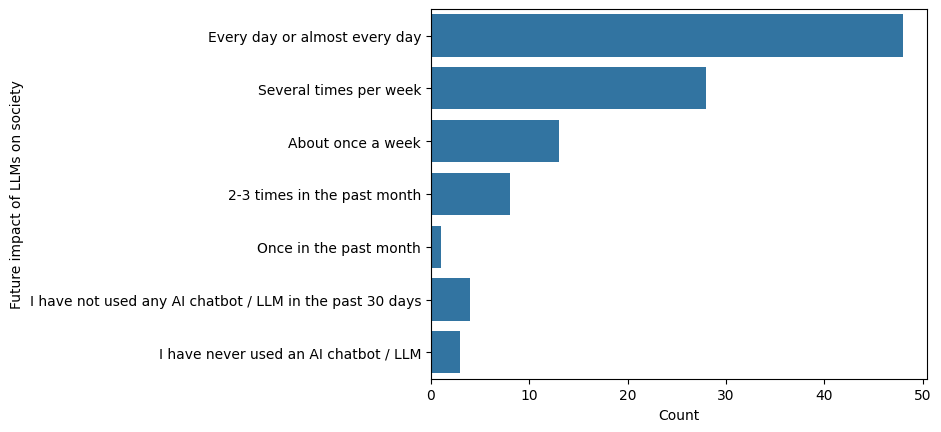

In [7]:
# display(data['LLM_use'].value_counts())

# define order of categories for LLM_use
llm_use_order = ["Every day or almost every day", 
                 "Several times per week", 
                 "About once a week", 
                 "2-3 times in the past month",
                 "Once in the past month",
                 "I have not used any AI chatbot / LLM in the past 30 days",
                 "I have never used an AI chatbot / LLM"]

# visualize
sns.countplot(y='LLM_use', data=data, order=llm_use_order)
plt.xlabel("Count")
plt.ylabel("Future impact of LLMs on society")
plt.show()

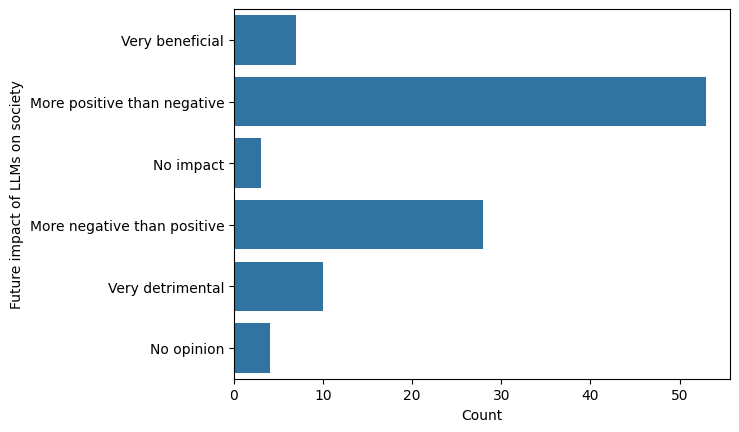

In [8]:
# display(data['LLM_impact'].value_counts())

# shorten the labels for better visualization
data['LLM_impact_abbrev'] = data['LLM_impact'].replace({
    "LLM chatbots will be very beneficial to society": "Very beneficial",
    "LLM chatbots will have more positive than negative effects on society": "More positive than negative",
    "LLM chatbots won't have any impact on society" : "No impact",
    "LLM chatbots will have more negative than positive effects on society": "More negative than positive",
    "LLM chatbots will be very detrimental to society": "Very detrimental",
    "I have no opinion on the impact of LLM chatbots on society": "No opinion"
}) 

# order categories
llm_impact_order = ["Very beneficial", 
                     "More positive than negative", 
                     "No impact", 
                     "More negative than positive", 
                     "Very detrimental", 
                     "No opinion"]

# visualize
sns.countplot(y='LLM_impact_abbrev', data=data, order=llm_impact_order)
plt.xlabel("Count")
plt.ylabel("Future impact of LLMs on society")
plt.show()

In [9]:
data['writing_style_pre'].value_counts()

writing_style_pre
Not at all    57
Somewhat      45
A lot          3
Name: count, dtype: int64

## Data quality (attention checks, bot/LLM involvement, response time)

### Response time

In [10]:
data['response_time_minutes'].describe()

count    105.000000
mean      22.214762
std       12.667331
min        7.450000
25%       13.683333
50%       18.366667
75%       27.583333
max       89.250000
Name: response_time_minutes, dtype: float64

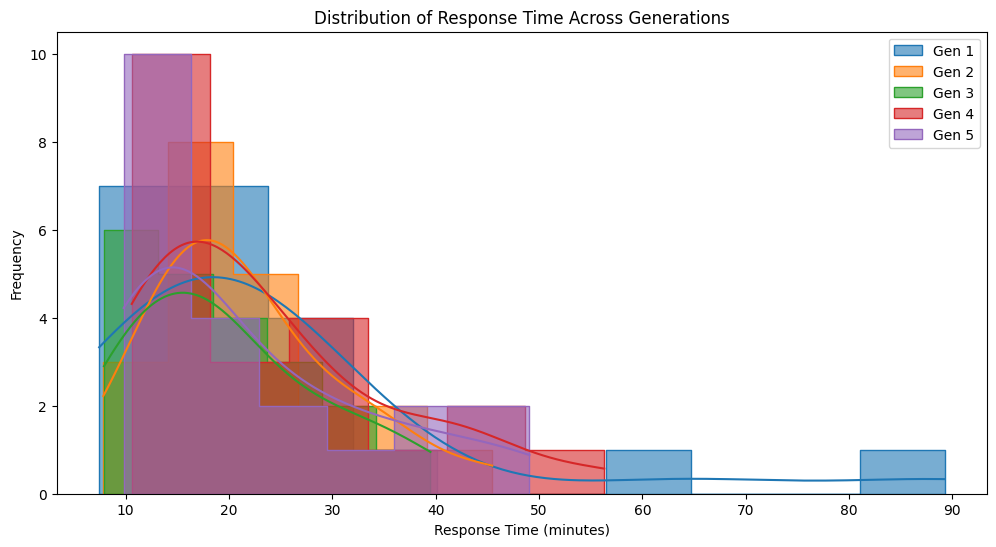

In [11]:
# plot response time distribution per generation
gens = sorted(data['g'].unique())
colors = sns.color_palette("tab10", n_colors=len(gens))
plt.figure(figsize=(12, 6))
for i, gen in enumerate(gens, start=1):
    sns.histplot(data=data[data['g'] == gen], x='response_time_minutes', color=colors[i-1], label=f'Gen {gen}', alpha=0.6, element='step', stat='count', kde=True)
plt.legend()
plt.title('Distribution of Response Time Across Generations')
plt.xlabel('Response Time (minutes)')
plt.ylabel('Frequency')
plt.show()

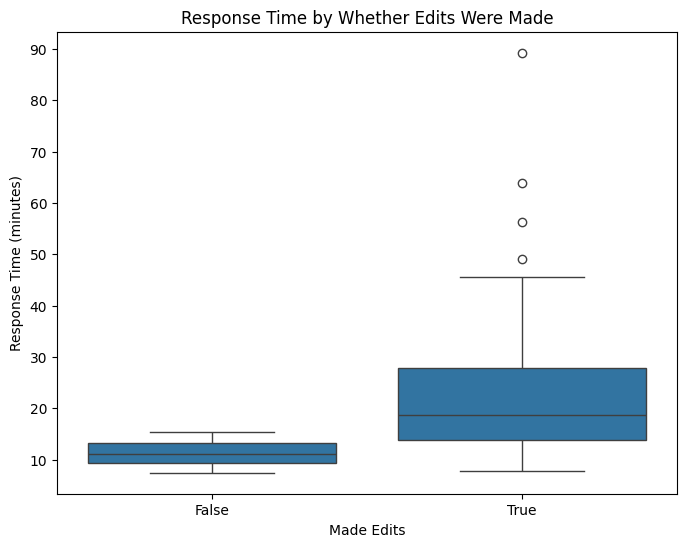

In [12]:
# response time given made edits or not
plt.figure(figsize=(8, 6))
sns.boxplot(x='made_edits', y='response_time_minutes', data=data)
plt.title('Response Time by Whether Edits Were Made')
plt.xlabel('Made Edits')
plt.ylabel('Response Time (minutes)')
plt.show()

In [13]:
edits_group = data[(data['stop_crit'] == 'No') & (data['made_edits'] == True)]['response_time_minutes']
no_edits_group = data[(data['stop_crit'] == 'No') & (data['made_edits'] == False)]['response_time_minutes']

print(f"Edits group: n = {len(edits_group)}, mean = {edits_group.mean():.2f}, SD = {edits_group.std():.2f}")
print(f"No-edits group: n = {len(no_edits_group)}, mean = {no_edits_group.mean():.2f}, SD = {no_edits_group.std():.2f}")

Edits group: n = 2, mean = 28.90, SD = 11.50
No-edits group: n = 3, mean = 11.34, SD = 4.01


In [14]:
# compute what a response time 1, 2, and 3 standard deviations away from the mean would be
subset = data[(data['made_edits'] == True) & (data['Q_RecaptchaScore'] == 1)]
# subset = responses

mean_response_time = subset['response_time_minutes'].mean()
std_response_time = subset['response_time_minutes'].std()
min_response_time = subset['response_time_minutes'].min()
print("Overall response time statistics:")
print(f"  Mean response time:  {mean_response_time:.2f} minutes")
print(f"  SD of response time: {std_response_time:.2f} minutes")
print(f"  Min response time:   {min_response_time:.2f} minutes")
print(f"  1 SD below mean:     {mean_response_time - std_response_time:.2f} minutes")
print(f"  2 SD below mean:     {mean_response_time - 2 * std_response_time:.2f} minutes")
print(f"  3 SD below mean:     {mean_response_time - 3 * std_response_time:.2f} minutes")

# the same per generation
for g in sorted(subset['g'].unique()):
    gen_responses = subset[subset['g'] == g]
    mean_response_time = gen_responses['response_time_minutes'].mean()
    std_response_time = gen_responses['response_time_minutes'].std()
    min_response_time = gen_responses['response_time_minutes'].min()
    print(f"\nGeneration {g}:")
    print(f"  Mean response time:  {mean_response_time:.2f} minutes")
    print(f"  SD of response time: {std_response_time:.2f} minutes")
    print(f"  Min response time:   {min_response_time:.2f} minutes")
    print(f"  1 SD below mean:     {mean_response_time - 1 * std_response_time:.2f} minutes")
    print(f"  2 SD below mean:     {mean_response_time - 2 * std_response_time:.2f} minutes")
    print(f"  3 SD below mean:     {mean_response_time - 3 * std_response_time:.2f} minutes")

Overall response time statistics:
  Mean response time:  22.80 minutes
  SD of response time: 12.95 minutes
  Min response time:   8.82 minutes
  1 SD below mean:     9.85 minutes
  2 SD below mean:     -3.10 minutes
  3 SD below mean:     -16.05 minutes

Generation 1:
  Mean response time:  25.59 minutes
  SD of response time: 19.90 minutes
  Min response time:   11.42 minutes
  1 SD below mean:     5.68 minutes
  2 SD below mean:     -14.22 minutes
  3 SD below mean:     -34.12 minutes

Generation 2:
  Mean response time:  22.40 minutes
  SD of response time: 8.92 minutes
  Min response time:   11.43 minutes
  1 SD below mean:     13.48 minutes
  2 SD below mean:     4.57 minutes
  3 SD below mean:     -4.35 minutes

Generation 3:
  Mean response time:  21.13 minutes
  SD of response time: 8.78 minutes
  Min response time:   8.82 minutes
  1 SD below mean:     12.34 minutes
  2 SD below mean:     3.56 minutes
  3 SD below mean:     -5.23 minutes

Generation 4:
  Mean response time:  

### Attention checks

In [15]:
# attention check 1: "To show that you are paying attention, please select 'Strongly disagree'"

# display(data['att1'].value_counts())

# if "Strongly disagree" -> passed, otherwise failed
data['att1_passed'] = data['att1'].apply(lambda x: 1 if x == "Strongly disagree" else 0)

passed = data[data['att1_passed'] == 1]
failed = data[data['att1_passed'] == 0]
print(f"Passed: {len(passed)}/{len(data)} -> {len(passed)/len(data)*100:.2f}%")
print(f"Failed: {len(failed)}/{len(data)} -> {len(failed)/len(data)*100:.2f}%")

Passed: 97/105 -> 92.38%
Failed: 8/105 -> 7.62%


In [16]:
# attention check 2: agreement with "I am 3 meters tall"
# display(data['att2'].value_counts())

# if "No" -> passed, otherwise failed
data['att2_passed'] = data['att2'].apply(lambda x: 1 if x == "No" else 0)

passed = data[data['att2_passed'] == 1]
failed = data[data['att2_passed'] == 0]
print(f"Passed: {len(passed)}/{len(data)} ({len(passed)/len(data)*100:.2f}%)")
print(f"Failed: {len(failed)}/{len(data)} ({len(failed)/len(data)*100:.2f}%)")

Passed: 99/105 (94.29%)
Failed: 6/105 (5.71%)


In [17]:
# overall attention check pass rate
data['passed_both_att_checks'] = data['att1_passed'] & data['att2_passed']
overall_passed = data[data['passed_both_att_checks'] == 1]
overall_failed = data[data['passed_both_att_checks'] == 0]
print(f"Passed both: {len(overall_passed)}/{len(data)} ({len(overall_passed)/len(data)*100:.2f}%)")

passed_only_att1 = data[(data['att1_passed'] == 1) & (data['att2_passed'] == 0)]
passed_only_att2 = data[(data['att1_passed'] == 0) & (data['att2_passed'] == 1)]
print(f"Passed only att1: {len(passed_only_att1)}/{len(data)} ({len(passed_only_att1)/len(data)*100:.2f}%)")
print(f"Passed only att2: {len(passed_only_att2)}/{len(data)} ({len(passed_only_att2)/len(data)*100:.2f}%)")

Passed both: 92/105 (87.62%)
Passed only att1: 5/105 (4.76%)
Passed only att2: 7/105 (6.67%)


### LLM use & bots

In [18]:
data['Q_RecaptchaScore'].describe()

count    105.000000
mean       0.960952
std        0.110502
min        0.300000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Q_RecaptchaScore, dtype: float64

In [19]:
data['if_genAI_used'].value_counts()

# NOTE: The one participant who reported using genAI was contacted after the experiment and confirmed that they had misunderstood the question and had not actually used genAI. Therefore, we consider all participants as not having used genAI.

if_genAI_used
No     104
Yes      1
Name: count, dtype: int64

In [20]:
data['response_quality'].value_counts()

response_quality
high_quality                    101
admitted_after_manual_review      4
Name: count, dtype: int64

NOTE: The respone quality rating was made based on a pre-defined rubric (see `process_responses_1_gen.ipynb`). Some participants were contacted after the experiment to clarify their responses, which resulted in admission of some additioal responses, which did not pass the automatic rubric-based rating. This was the case for 4 responses: 
- Two participants (gen 3 and gen 4) were flagged based on a low Q_RecaptchaScore, however no further evidence of bot-like behavior was found: the participants provided coherent and thorough responses, one of which (gen 4) taking double the estimated completion time.
- One participant (gen 4) failed both attention checks but provided coherent and thorough responses, taking double the estimated completion time. They claimed having misread these questions, but assured that they had paid attention to the main task instructions and completed the main task to the best of their abilities. 
- The last manually included participant (gen 5) was initially rejected on the grounds of reported genAI use, however they clarified that they had misunderstood the question and had not actually used genAI. 

## Task-related

In [21]:
data.groupby('g')['made_edits'].value_counts()

for g in sorted(data['g'].unique()):
    print(f"Generation {g}: {data[(data['g'] == g) & (data['made_edits'] == 1)].shape[0]} participants made edits")

Generation 1: 20 participants made edits
Generation 2: 21 participants made edits
Generation 3: 21 participants made edits
Generation 4: 20 participants made edits
Generation 5: 20 participants made edits


In [22]:
# responses['stop_crit'].value_counts()

# generation and chain of "No" response to stop criterion (considered their editing unsuccessful)
data['num_edited_sentences'] = data['decoded_explanations'].apply(lambda x: len(ast.literal_eval(x))) 
data[data['stop_crit'] == "No"][['g', 'c', 'made_edits', 'num_edited_sentences', 'response_time_minutes', 'remarks']]

,g,c,made_edits,num_edited_sentences,response_time_minutes,remarks
14,1,15,False,0,7.450000,I thought the generated text was formal and su...
70,4,8,False,0,15.466667,NaN
90,5,7,True,7,20.766667,NaN
96,5,13,False,0,11.100000,NaN
101,5,18,True,13,37.033333,NaN


In [23]:
data[(data['stop_crit'] == "No") & (data['made_edits'] == True)]['response_time_minutes'].describe()

count     2.000000
mean     28.900000
std      11.502270
min      20.766667
25%      24.833333
50%      28.900000
75%      32.966667
max      37.033333
Name: response_time_minutes, dtype: float64

## Post-task reflections

In [24]:
# display(data['writing_style_post'].value_counts())
print(f"Participants who responded that their wrting style may change after this experiment: {data[data['writing_style_post'] != 'No'].shape[0]}.")

print("Their explanations:")
for answer in data[data['writing_style_post_1_TEXT'].notnull()]['writing_style_post_1_TEXT'].values:
    print(f"- {answer}")

Participants who responded that their wrting style may change after this experiment: 4.
Their explanations:
- It will improve the findings
- The text will sound more natural. 
- It will make me aware of the fact that LLMs cannot replicate the emotion behind text that a real human can provide.
- I may use more punctuation to maybe sound more formal at work 


In [25]:
for remark in data[data['remarks'].notnull()]['remarks']:
    gen = data[data['remarks'] == remark]['g'].values[0]
    print(f"- (gen {gen}) {remark}")

- (gen 1) Its a very thin line now between whats produced by humans and whats generated by AI models, so good luck.
- (gen 1) The text overall did feel very human as much as a factual text can be. It reminds me of writing college essays, sometimes they feel a bit robotic because you are basically writing facts and quotes. It's a tough line to walk as ai improves but I think people should still aim to write essays themselves to learn and improve their writing style, regardless of whether is comes across as ai written or not. 
- (gen 1) to do that study really really properly i think would take like twice the amount of time estimated!
- (gen 1) None.
- (gen 1) Very engaging and interesting study
- (gen 1) Thank you. Very interesting! 
- (gen 1) I enjoyed reading the AI version and making subtle changes to make it appear less robotic.
- (gen 1) I thought the generated text was formal and suits the context of the article, which suits the grammar of the AI model.
- (gen 1) AI as a tool is g

# Save processed data

In [26]:
data.to_csv(processed_data_path, index=False)